> **Recorded AWS execution — 20260920-013145.** This notebook preserves the original code and scientific outputs. It is an evidence snapshot, not a claim that a data-free clone can rerun the private workspace. Start with [the portfolio overview](00_portfolio_overview.ipynb); see [reproduction instructions](../docs/REPRODUCIBILITY.md) and [current status](../docs/STATUS.md).


# Notebook 25 · Preserve the public association signal, test our residual features

**Question.** Can original representations correct specific association errors without replacing a stronger frozen public probability? Previously, cached dual-seed bidirectional probabilities achieved 0.975 macro development edge Jaccard, while the best fitted hybrid achieved 0.943085. These are two-sample exploratory scores, not official leaderboard results.

**Boundary.** The cached detector/association configuration differs from the full byte-identical Harmonic Fusion reference: threshold, augmentation and post-processing are not identical. This notebook integrates at the cached association component level only. The two development sample IDs also occur in the reproduced test manifest; public-checkpoint training independence is not established. No result below authorizes a leaderboard submission or claims clean independent generalization.

## Fixed hypothesis and four-fit ablation

Compare the frozen probability against a ridge-logistic **offset** model using the 32 existing public-score features, then the same model using all 557 features (including 525 original features). The public logit is an offset, not a fitted coefficient. Each variant receives two leave-one-sample-out fits. Preprocessing is fit only on labeled training rows: median imputation, standardization, zeroing constant/all-missing columns, clipping to 10 standard deviations, and normalization by the square root of each block size (32 public and 525 original). The public-feature scaling remains identical when the original block is added. The objective is mean unweighted Bernoulli log loss plus L2 penalty 0.1; the intercept is penalized. At prediction, the correction is clipped to ±log(2), so anchor odds change by at most a factor of two. The clipping safeguard can make the deployed prediction differ from the unconstrained fitted objective; both raw and clipped corrections are retained.

Each fold uses one threshold chosen solely from training labels and frozen anchor probabilities, shared by all variants. Unknown edges are never negative training examples but remain competitors in the degree-constrained decoder. A model is saved only after finite objective/gradient/weights and successful optimization checks.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import Image, display
OUT=Path('/home/sagemaker-user/biohub-cell-tracking-during-development/outputs/anchored_association/runs/20260920T012531_422521Z')
def show(fig, height=550, left=100):
    fig.update_layout(width=1040,height=height,margin=dict(l=left,r=40,t=105,b=110))
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore",category=DeprecationWarning)
        png=fig.to_image(format="png",width=1040,height=height,scale=1)
    display(Image(data=png))
    print("PERSISTENT_PNG_BYTES",len(png))
metrics=pd.read_csv(OUT/"fold_metrics.csv")
aggregate=pd.read_csv(OUT/"aggregate_metrics.csv")
coeff=pd.read_csv(OUT/"coefficients.csv")
result=json.loads((OUT/"experiment_result.json").read_text())
ledger=json.loads((OUT/"standing.json").read_text())
protocol=json.loads((OUT/"protocol.json").read_text())
print("EVALUATION: two within-embryo development samples; strict labeled edges only.")
print("OFFICIAL_ACCOUNT_SCORE",ledger.get("own_best_retrieved_public_score"))
print("PUBLIC_LEADER_SNAPSHOT",ledger.get("public_leader_score"),ledger.get("observed_utc"))
print("Independent checkpoint-training provenance is not established.")
print(metrics[["valid_sample","variant","threshold","tp","fp","fn","decoded_labeled_edge_jaccard","brier"]].to_string(index=False,float_format=lambda x:f"{x:.6f}"))
labels={"cached_harmonic_anchor":"Frozen cached association","residual_public32":"Bounded correction · public 32","residual_all557":"Bounded correction · all 557"}


EVALUATION: two within-embryo development samples; strict labeled edges only.
OFFICIAL_ACCOUNT_SCORE None
PUBLIC_LEADER_SNAPSHOT 0.974 2026-09-20T00:47:46+00:00
Independent checkpoint-training provenance is not established.
 valid_sample                variant  threshold  tp  fp  fn  decoded_labeled_edge_jaccard    brier
6bba_05db0fb1 cached_harmonic_anchor   0.020000  47   0   0                      1.000000 0.013945
6bba_05b6850b cached_harmonic_anchor   0.400000  38   0   2                      0.950000 0.044491
6bba_05db0fb1      residual_public32   0.020000  47   0   0                      1.000000 0.006130
6bba_05db0fb1        residual_all557   0.020000  47   0   0                      1.000000 0.005839
6bba_05b6850b      residual_public32   0.400000  38   0   2                      0.950000 0.035902
6bba_05b6850b        residual_all557   0.400000  38   0   2                      0.950000 0.036432


## Matched control and evaluation

The unchanged cached control must reproduce historical macro edge Jaccard 0.975 before any new fit. The per-window decoder maximizes threshold-relative log odds with at most one parent and two children. It must finish with an optimal solution, not merely return a feasible vector. Evaluation counts TP/FP/FN only on the 134 strictly labeled candidate edges; it omits full official node-count and division scoring.

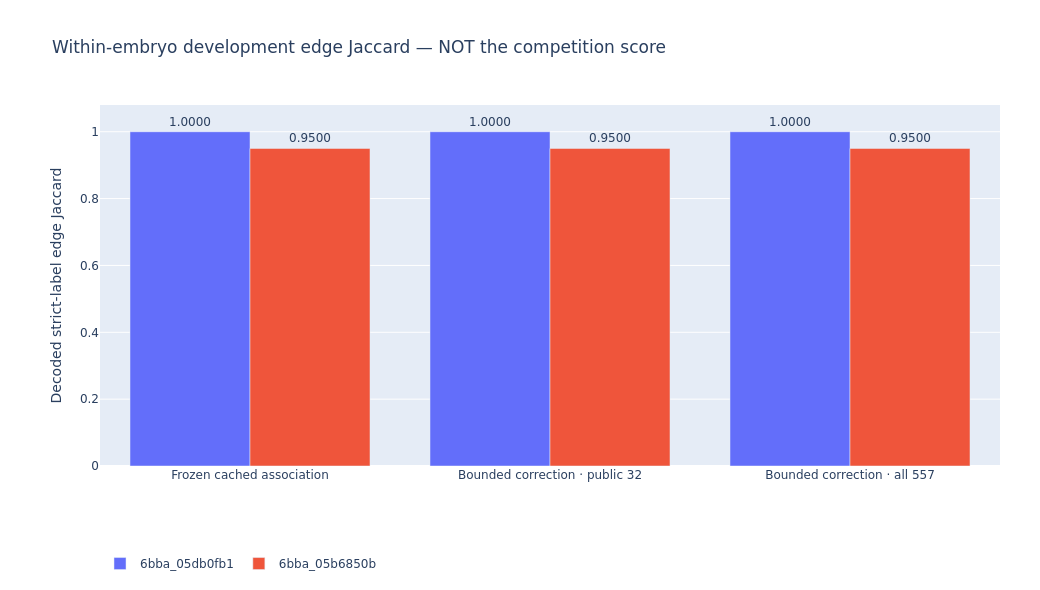

PERSISTENT_PNG_BYTES 53337


In [2]:
order=["cached_harmonic_anchor","residual_public32","residual_all557"]
fig=go.Figure()
for sample in metrics.valid_sample.unique():
    subset=metrics[metrics.valid_sample==sample].set_index("variant").reindex(order)
    fig.add_bar(x=[labels[x] for x in order],y=subset.decoded_labeled_edge_jaccard.to_numpy(),name=str(sample),text=[f"{x:.4f}" for x in subset.decoded_labeled_edge_jaccard],textposition="outside")
fig.update_layout(title="Within-embryo development edge Jaccard — NOT the competition score",barmode="group",legend=dict(orientation="h",y=-.23))
fig.update_yaxes(title="Decoded strict-label edge Jaccard",range=[0,1.08])
show(fig,height=590)


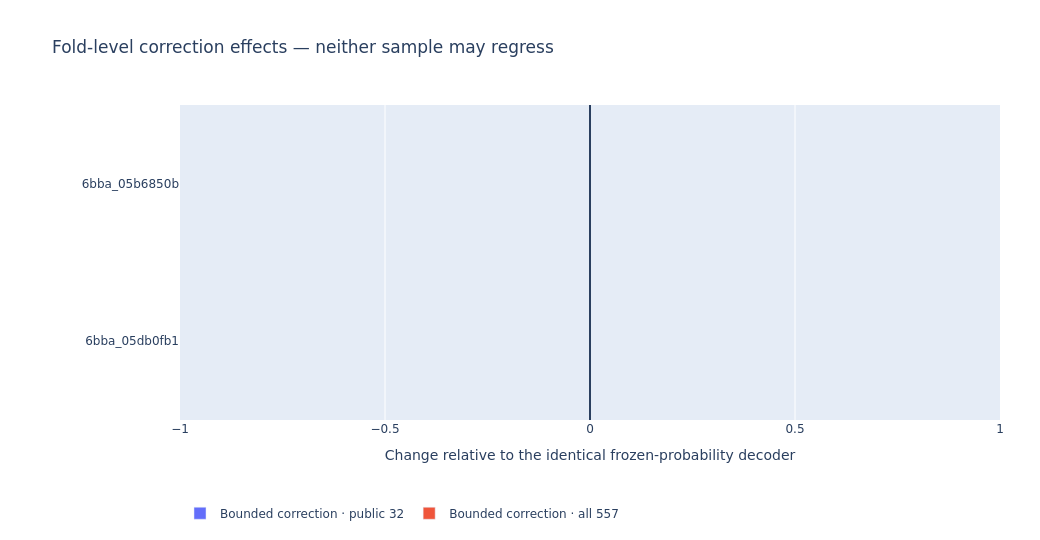

PERSISTENT_PNG_BYTES 39272
THRESHOLDS: selected on training anchor only, reused unchanged across variants.


In [3]:
base=metrics[metrics.variant=="cached_harmonic_anchor"].set_index("valid_sample").decoded_labeled_edge_jaccard
fig=go.Figure()
for variant in ["residual_public32","residual_all557"]:
    sub=metrics[metrics.variant==variant]
    delta=[float(row.decoded_labeled_edge_jaccard-base[row.valid_sample]) for row in sub.itertuples()]
    fig.add_bar(y=sub.valid_sample,x=delta,name=labels[variant],orientation="h",text=[f"{v:+.6f}" for v in delta],textposition="auto")
fig.add_vline(x=0)
fig.update_layout(title="Fold-level correction effects — neither sample may regress",barmode="group",legend=dict(orientation="h",y=-.25))
fig.update_xaxes(title="Change relative to the identical frozen-probability decoder")
show(fig,height=540,left=180)
print("THRESHOLDS: selected on training anchor only, reused unchanged across variants.")


## What did the correction use?

The feature-family comparison, not coefficient magnitude, tests incremental value. All original engineered features are reused from the cached dataset rather than regenerated or discarded. The frozen full-reference CSV remains byte-identical.

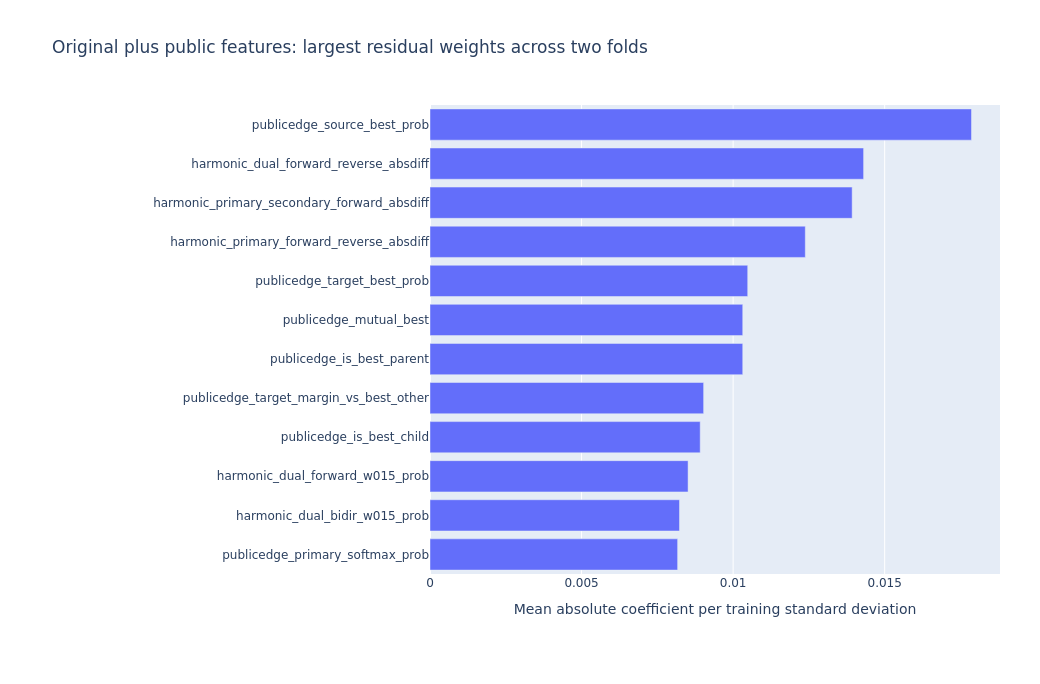

PERSISTENT_PNG_BYTES 75283
Coefficient size is a diagnostic, not a causal effect or validation evidence.


In [4]:
sub=coeff[(coeff.variant=="residual_all557") & (coeff.feature!="intercept")].copy()
sub["absolute_weight"]=sub.coefficient_per_standard_deviation.abs()
top=sub.groupby("feature").absolute_weight.mean().nlargest(12).sort_values()
import textwrap
names=["<br>".join(textwrap.wrap(str(x),54)) for x in top.index]
fig=go.Figure(go.Bar(y=names,x=top.values,orientation="h"))
fig.update_layout(title="Original plus public features: largest residual weights across two folds")
fig.update_xaxes(title="Mean absolute coefficient per training standard deviation")
show(fig,height=max(600,42*len(top)+180),left=430)
print("Coefficient size is a diagnostic, not a causal effect or validation evidence.")


## Promotion, rejection and unresolved work

A positive development screen requires the all-feature correction to avoid regression on either sample fold, improve at least one, and outperform the public-feature-only residual on macro Jaccard. Even then, the next permitted step is an independent benchmark with documented model-training and test separation—not application to the reference submission. Any fold degradation rejects this fixed residual configuration. Ties or lack of original-feature improvement retain the frozen anchor and redirect research. There is no significance claim from two development samples, no unseen hyperparameter sweep and no full-data refit. Official standing requires an actual accepted Kaggle score; historical notebook labels are not account scores.

In [5]:
print("DECISION",result["next_decision"])
print("NEW_CPU_FITS",result["new_fits"],"REUSED_MODELS",result["reused_models"])
print("ORIGINAL_FEATURE_DELTA_VS_PUBLIC32",result["all557_minus_public32_macro"])
print("ORIGINAL_FEATURE_HYPOTHESIS_SURVIVED",result["original_feature_hypothesis_survived_development_gate"])
print("Full public 0.947 inference pipeline was not modified or run in this experiment.")
print("No residual correction is authorized for the reference submission.")
print("BIOHUB_ANCHORED_NOTEBOOK_COMPLETE")


DECISION no_consistent_original_feature_gain_keep_frozen_anchor
NEW_CPU_FITS 4 REUSED_MODELS 0
ORIGINAL_FEATURE_DELTA_VS_PUBLIC32 0.0
ORIGINAL_FEATURE_HYPOTHESIS_SURVIVED False
Full public 0.947 inference pipeline was not modified or run in this experiment.
No residual correction is authorized for the reference submission.
BIOHUB_ANCHORED_NOTEBOOK_COMPLETE
